In [1]:
import os
import pickle
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_float32_matmul_precision("high")

c:\Users\vlada\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


In [2]:
@dataclass
class Config:
    seed: int = int(os.getenv("SEED", "42"))
    batch_size: int = int(os.getenv("BATCH_SIZE", "128"))
    num_workers: int = int(os.getenv("NUM_WORKERS", "0"))
    lr: float = float(os.getenv("LR", "1e-3"))
    weight_decay: float = float(os.getenv("WEIGHT_DECAY", "1e-4"))
    epochs: int = int(os.getenv("EPOCHS", "12"))
    patch_size: int = int(os.getenv("PATCH_SIZE", "8"))
    patch_alpha: float = float(os.getenv("PATCH_ALPHA", "1.0"))
    train_subset: Optional[int] = int(os.getenv("TRAIN_SUBSET", "0")) or None
    test_subset: Optional[int] = int(os.getenv("TEST_SUBSET", "0")) or None
    checkpoint_dir: Path = Path("artifacts")
    data_dir: Path = Path("data") / "cifar-10-batches-py"
    force_retrain: bool = os.getenv("FORCE_RETRAIN", "0") == "1"
    cam_examples: int = int(os.getenv("CAM_EXAMPLES", "5"))
    confidence_drop_samples: int = int(os.getenv("CONF_DROP_SAMPLES", "128"))
    top_fraction: float = float(os.getenv("TOP_FRACTION", "0.2"))


cfg = Config()
cfg.checkpoint_dir.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Config:")
for key, value in asdict(cfg).items():
    print(f"  {key}: {value}")

Device: cuda
Config:
  seed: 42
  batch_size: 128
  num_workers: 0
  lr: 0.001
  weight_decay: 0.0001
  epochs: 12
  patch_size: 8
  patch_alpha: 1.0
  train_subset: None
  test_subset: None
  checkpoint_dir: artifacts
  data_dir: data\cifar-10-batches-py
  force_retrain: False
  cam_examples: 5
  confidence_drop_samples: 128
  top_fraction: 0.2


In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

CLASS_COLORS = np.array(
    [
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [255, 255, 0],
        [255, 0, 255],
        [0, 255, 255],
        [255, 128, 0],
        [128, 0, 255],
        [0, 128, 255],
        [255, 255, 255],
    ],
    dtype=np.uint8,
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)


def denormalize_image(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR_MEAN, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD, device=tensor.device).view(3, 1, 1)
    return (tensor * std + mean).clamp(0.0, 1.0)

In [4]:
def _read_pickle(path: Path) -> Dict:
    with open(path, "rb") as handle:
        return pickle.load(handle, encoding="bytes")


def _get_key(obj: Dict, byte_key: bytes, str_key: str):
    if byte_key in obj:
        return obj[byte_key]
    return obj[str_key]


def load_cifar10_from_disk(root: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    if not root.exists():
        raise FileNotFoundError(f"Expected CIFAR-10 batches in {root.resolve()}, but the folder does not exist.")

    train_images = []
    train_labels = []
    for batch_idx in range(1, 6):
        batch = _read_pickle(root / f"data_batch_{batch_idx}")
        data = _get_key(batch, b"data", "data")
        labels = np.array(_get_key(batch, b"labels", "labels"), dtype=np.int64)
        images = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        train_images.append(images)
        train_labels.append(labels)

    test_batch = _read_pickle(root / "test_batch")
    test_images = _get_key(test_batch, b"data", "data").reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    test_labels = np.array(_get_key(test_batch, b"labels", "labels"), dtype=np.int64)

    meta = _read_pickle(root / "batches.meta")
    raw_names = _get_key(meta, b"label_names", "label_names")
    class_names = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in raw_names]

    train_images = np.concatenate(train_images, axis=0).astype(np.uint8)
    train_labels = np.concatenate(train_labels, axis=0)
    test_images = test_images.astype(np.uint8)
    return train_images, train_labels, test_images, test_labels, class_names


train_images, train_labels, test_images, test_labels, class_names = load_cifar10_from_disk(cfg.data_dir)
print("Train set:", train_images.shape, train_labels.shape)
print("Test set :", test_images.shape, test_labels.shape)
print("Classes  :", class_names)

Train set: (50000, 32, 32, 3) (50000,)
Test set : (10000, 32, 32, 3) (10000,)
Classes  : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
def stratified_subset(images: np.ndarray, labels: np.ndarray, subset_size: Optional[int], seed: int):
    if subset_size is None or subset_size >= len(labels):
        return images, labels

    rng = np.random.default_rng(seed)
    indices_by_class = [np.where(labels == class_idx)[0] for class_idx in range(len(np.unique(labels)))]
    per_class = max(subset_size // len(indices_by_class), 1)

    selected = []
    for indices in indices_by_class:
        take = min(len(indices), per_class)
        selected.extend(rng.choice(indices, size=take, replace=False).tolist())

    if len(selected) < subset_size:
        remaining = np.setdiff1d(np.arange(len(labels)), np.array(selected), assume_unique=False)
        extra = rng.choice(remaining, size=subset_size - len(selected), replace=False)
        selected.extend(extra.tolist())

    selected = np.array(selected[:subset_size])
    rng.shuffle(selected)
    return images[selected], labels[selected]


train_images_used, train_labels_used = stratified_subset(train_images, train_labels, cfg.train_subset, cfg.seed)
test_images_used, test_labels_used = stratified_subset(test_images, test_labels, cfg.test_subset, cfg.seed + 1)

print("Working train set:", train_images_used.shape)
print("Working test set :", test_images_used.shape)

Working train set: (50000, 32, 32, 3)
Working test set : (10000, 32, 32, 3)


In [6]:
def add_class_patch(
    images: np.ndarray,
    labels: np.ndarray,
    colors: np.ndarray,
    patch_size: int = 8,
    alpha: float = 1.0,
    location: str = "bottom_right",
) -> np.ndarray:
    if location not in {"bottom_right", "top_left"}:
        raise ValueError("location must be 'bottom_right' or 'top_left'")

    biased = images.copy().astype(np.float32)
    if location == "bottom_right":
        y0, x0 = images.shape[1] - patch_size, images.shape[2] - patch_size
    else:
        y0, x0 = 0, 0

    for idx, label in enumerate(labels):
        patch_color = colors[label].reshape(1, 1, 3).astype(np.float32)
        original_patch = biased[idx, y0:y0 + patch_size, x0:x0 + patch_size, :]
        biased[idx, y0:y0 + patch_size, x0:x0 + patch_size, :] = (1.0 - alpha) * original_patch + alpha * patch_color

    return biased.clip(0, 255).astype(np.uint8)


biased_train_images = add_class_patch(train_images_used, train_labels_used, CLASS_COLORS, patch_size=cfg.patch_size, alpha=cfg.patch_alpha)
biased_test_images = add_class_patch(test_images_used, test_labels_used, CLASS_COLORS, patch_size=cfg.patch_size, alpha=cfg.patch_alpha)

In [7]:
class CIFARArrayDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images = images
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index: int):
        image = self.images[index]
        label = int(self.labels[index])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


clean_train_dataset = CIFARArrayDataset(train_images_used, train_labels_used, transform=transform)
biased_train_dataset = CIFARArrayDataset(biased_train_images, train_labels_used, transform=transform)
clean_test_dataset = CIFARArrayDataset(test_images_used, test_labels_used, transform=transform)
biased_test_dataset = CIFARArrayDataset(biased_test_images, test_labels_used, transform=transform)


def build_loader(dataset: Dataset, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )


clean_train_loader = build_loader(clean_train_dataset, shuffle=True)
biased_train_loader = build_loader(biased_train_dataset, shuffle=True)
clean_test_loader = build_loader(clean_test_dataset, shuffle=False)
biased_test_loader = build_loader(biased_test_dataset, shuffle=False)

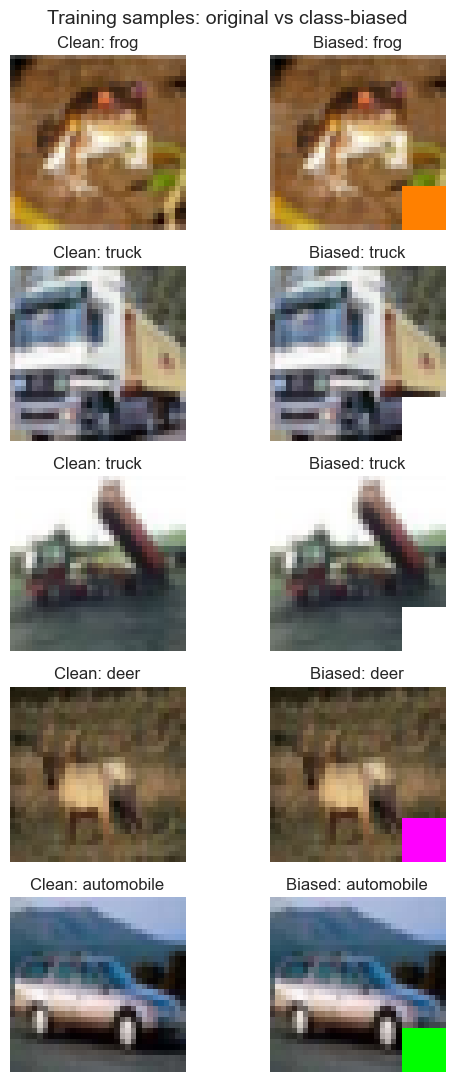

In [8]:
def show_dataset_examples(clean_images: np.ndarray, biased_images: np.ndarray, labels: np.ndarray, classes: List[str], n: int = 5):
    fig, axes = plt.subplots(n, 2, figsize=(6, 2.2 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row in range(n):
        axes[row, 0].imshow(clean_images[row])
        axes[row, 0].set_title(f"Clean: {classes[int(labels[row])]}")
        axes[row, 1].imshow(biased_images[row])
        axes[row, 1].set_title(f"Biased: {classes[int(labels[row])]}")
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")

    fig.suptitle("Training samples: original vs class-biased", fontsize=14)
    fig.tight_layout()
    plt.show()


show_dataset_examples(train_images_used, biased_train_images, train_labels_used, class_names, n=5)

In [9]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.35),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    @property
    def target_layer(self):
        return self.features[14]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


model = SmallCNN().to(device)
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddin

In [10]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, device: torch.device) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


def fit_model(model: nn.Module, train_loader: DataLoader, eval_loader: DataLoader, name: str, epochs: int, lr: float, weight_decay: float, device: torch.device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        eval_metrics = evaluate(model, eval_loader, criterion, device)
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "eval_loss": eval_metrics["loss"],
            "eval_acc": eval_metrics["accuracy"],
        }
        history.append(row)
        print(
            f"[{name}] epoch {epoch:02d}/{epochs} | "
            f"train loss {row['train_loss']:.4f} | train acc {row['train_acc']:.4f} | "
            f"eval loss {row['eval_loss']:.4f} | eval acc {row['eval_acc']:.4f}"
        )

    return history


def train_or_load_model(name: str, train_loader: DataLoader, eval_loader: DataLoader, device: torch.device) -> Tuple[nn.Module, List[Dict[str, float]]]:
    checkpoint_path = cfg.checkpoint_dir / f"{name}_cnn_v2.pt"
    model = SmallCNN().to(device)

    if checkpoint_path.exists() and not cfg.force_retrain:
        payload = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(payload["model_state_dict"])
        history = payload.get("history", [])
        print(f"Loaded checkpoint from {checkpoint_path}")
        return model, history

    history = fit_model(
        model=model,
        train_loader=train_loader,
        eval_loader=eval_loader,
        name=name,
        epochs=cfg.epochs,
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
        device=device,
    )
    torch.save(
        {"model_state_dict": model.state_dict(), "history": history, "config": asdict(cfg)},
        checkpoint_path,
    )
    print(f"Saved checkpoint to {checkpoint_path}")
    return model, history

In [11]:
clean_model, clean_history = train_or_load_model(name="clean", train_loader=clean_train_loader, eval_loader=clean_test_loader, device=device)
biased_model, biased_history = train_or_load_model(name="biased", train_loader=biased_train_loader, eval_loader=clean_test_loader, device=device)

[clean] epoch 01/12 | train loss 1.3884 | train acc 0.4947 | eval loss 1.2484 | eval acc 0.5741
[clean] epoch 02/12 | train loss 0.9419 | train acc 0.6701 | eval loss 0.9027 | eval acc 0.6812
[clean] epoch 03/12 | train loss 0.7723 | train acc 0.7325 | eval loss 0.7655 | eval acc 0.7346
[clean] epoch 04/12 | train loss 0.6716 | train acc 0.7684 | eval loss 0.8265 | eval acc 0.7108
[clean] epoch 05/12 | train loss 0.5833 | train acc 0.7992 | eval loss 0.6194 | eval acc 0.7891
[clean] epoch 06/12 | train loss 0.5238 | train acc 0.8212 | eval loss 0.6253 | eval acc 0.7941
[clean] epoch 07/12 | train loss 0.4559 | train acc 0.8454 | eval loss 0.6420 | eval acc 0.7880
[clean] epoch 08/12 | train loss 0.4079 | train acc 0.8605 | eval loss 0.5666 | eval acc 0.8089
[clean] epoch 09/12 | train loss 0.3593 | train acc 0.8776 | eval loss 0.5360 | eval acc 0.8235
[clean] epoch 10/12 | train loss 0.3109 | train acc 0.8926 | eval loss 0.5995 | eval acc 0.8136
[clean] epoch 11/12 | train loss 0.2685 

In [12]:
criterion = nn.CrossEntropyLoss()
clean_on_clean = evaluate(clean_model, clean_test_loader, criterion, device)
biased_on_clean = evaluate(biased_model, clean_test_loader, criterion, device)
biased_on_biased = evaluate(biased_model, biased_test_loader, criterion, device)

print("Evaluation summary")
print("-" * 60)
print(f"Clean model  on clean test : acc={clean_on_clean['accuracy']:.4f}, loss={clean_on_clean['loss']:.4f}")
print(f"Biased model on clean test : acc={biased_on_clean['accuracy']:.4f}, loss={biased_on_clean['loss']:.4f}")
print(f"Biased model on patched test: acc={biased_on_biased['accuracy']:.4f}, loss={biased_on_biased['loss']:.4f}")

Evaluation summary
------------------------------------------------------------
Clean model  on clean test : acc=0.7925, loss=0.6993
Biased model on clean test : acc=0.1393, loss=2.8454
Biased model on patched test: acc=1.0000, loss=0.0000


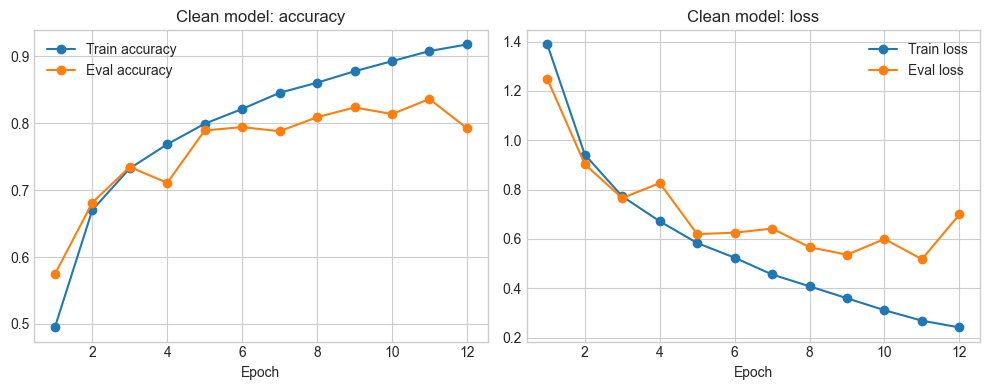

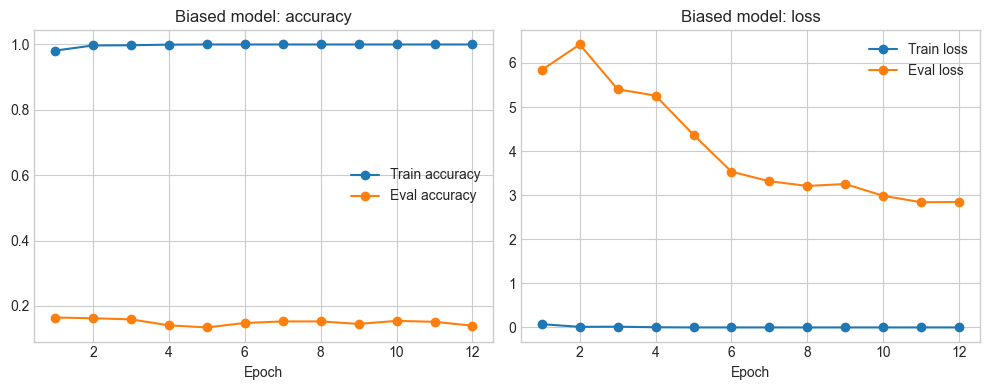

In [13]:
def plot_history(history: List[Dict[str, float]], title: str):
    if not history:
        print(f"No stored history for {title}.")
        return

    epochs = [row["epoch"] for row in history]
    train_acc = [row["train_acc"] for row in history]
    eval_acc = [row["eval_acc"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    eval_loss = [row["eval_loss"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, train_acc, marker="o", label="Train accuracy")
    axes[0].plot(epochs, eval_acc, marker="o", label="Eval accuracy")
    axes[0].set_title(f"{title}: accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, train_loss, marker="o", label="Train loss")
    axes[1].plot(epochs, eval_loss, marker="o", label="Eval loss")
    axes[1].set_title(f"{title}: loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.tight_layout()
    plt.show()


plot_history(clean_history, "Clean model")
plot_history(biased_history, "Biased model")

## Manual Grad-CAM

We implement the standard Grad-CAM procedure from the original paper:

$$
\alpha_k^c = \frac{1}{Z} \, \sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}
$$

$$
L^c_{Grad-CAM} = ReLU\left( \sum_k \alpha_k^c A^k \right)
$$

Here:

- $A^k$ are the feature maps of the last convolutional layer,
- $y^c$ is the logit for class $c$,
- the gradient is globally averaged over spatial locations to obtain channel importance weights.

In [14]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor: torch.Tensor, target_class: Optional[int] = None) -> np.ndarray:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        score = logits[:, target_class].sum()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(0).squeeze(0)
        cam -= cam.min()
        cam /= cam.max().clamp(min=1e-8)
        return cam.detach().cpu().numpy()

    def remove(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [15]:
def overlay_heatmap(image_tensor: torch.Tensor, cam_map: np.ndarray, alpha: float = 0.45):
    base = denormalize_image(image_tensor.detach().cpu()).permute(1, 2, 0).numpy()
    cmap = plt.get_cmap("jet")
    colorized = cmap(cam_map)[..., :3]
    overlay = (1 - alpha) * base + alpha * colorized
    return base, colorized, np.clip(overlay, 0.0, 1.0)


@torch.no_grad()
def predict_with_confidence(model: nn.Module, image_tensor: torch.Tensor):
    logits = model(image_tensor.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1)[0].detach().cpu()
    pred_idx = int(probs.argmax().item())
    return pred_idx, float(probs[pred_idx].item())

In [16]:
def pick_correct_examples(model: nn.Module, dataset: Dataset, labels: np.ndarray, per_class: int = 1, max_scan: int = 2000) -> List[int]:
    found = []
    covered = set()

    for idx in range(min(len(dataset), max_scan)):
        image, label = dataset[idx]
        pred, _ = predict_with_confidence(model, image)
        if pred == label and label not in covered:
            found.append(idx)
            covered.add(label)
        if len(found) >= per_class * len(np.unique(labels)):
            break

    if len(found) < cfg.cam_examples:
        for idx in range(len(dataset)):
            if idx not in found:
                found.append(idx)
            if len(found) >= cfg.cam_examples:
                break

    return found[: cfg.cam_examples]


example_indices = pick_correct_examples(clean_model, clean_test_dataset, test_labels_used)
example_indices

[0, 1, 4, 6, 10]

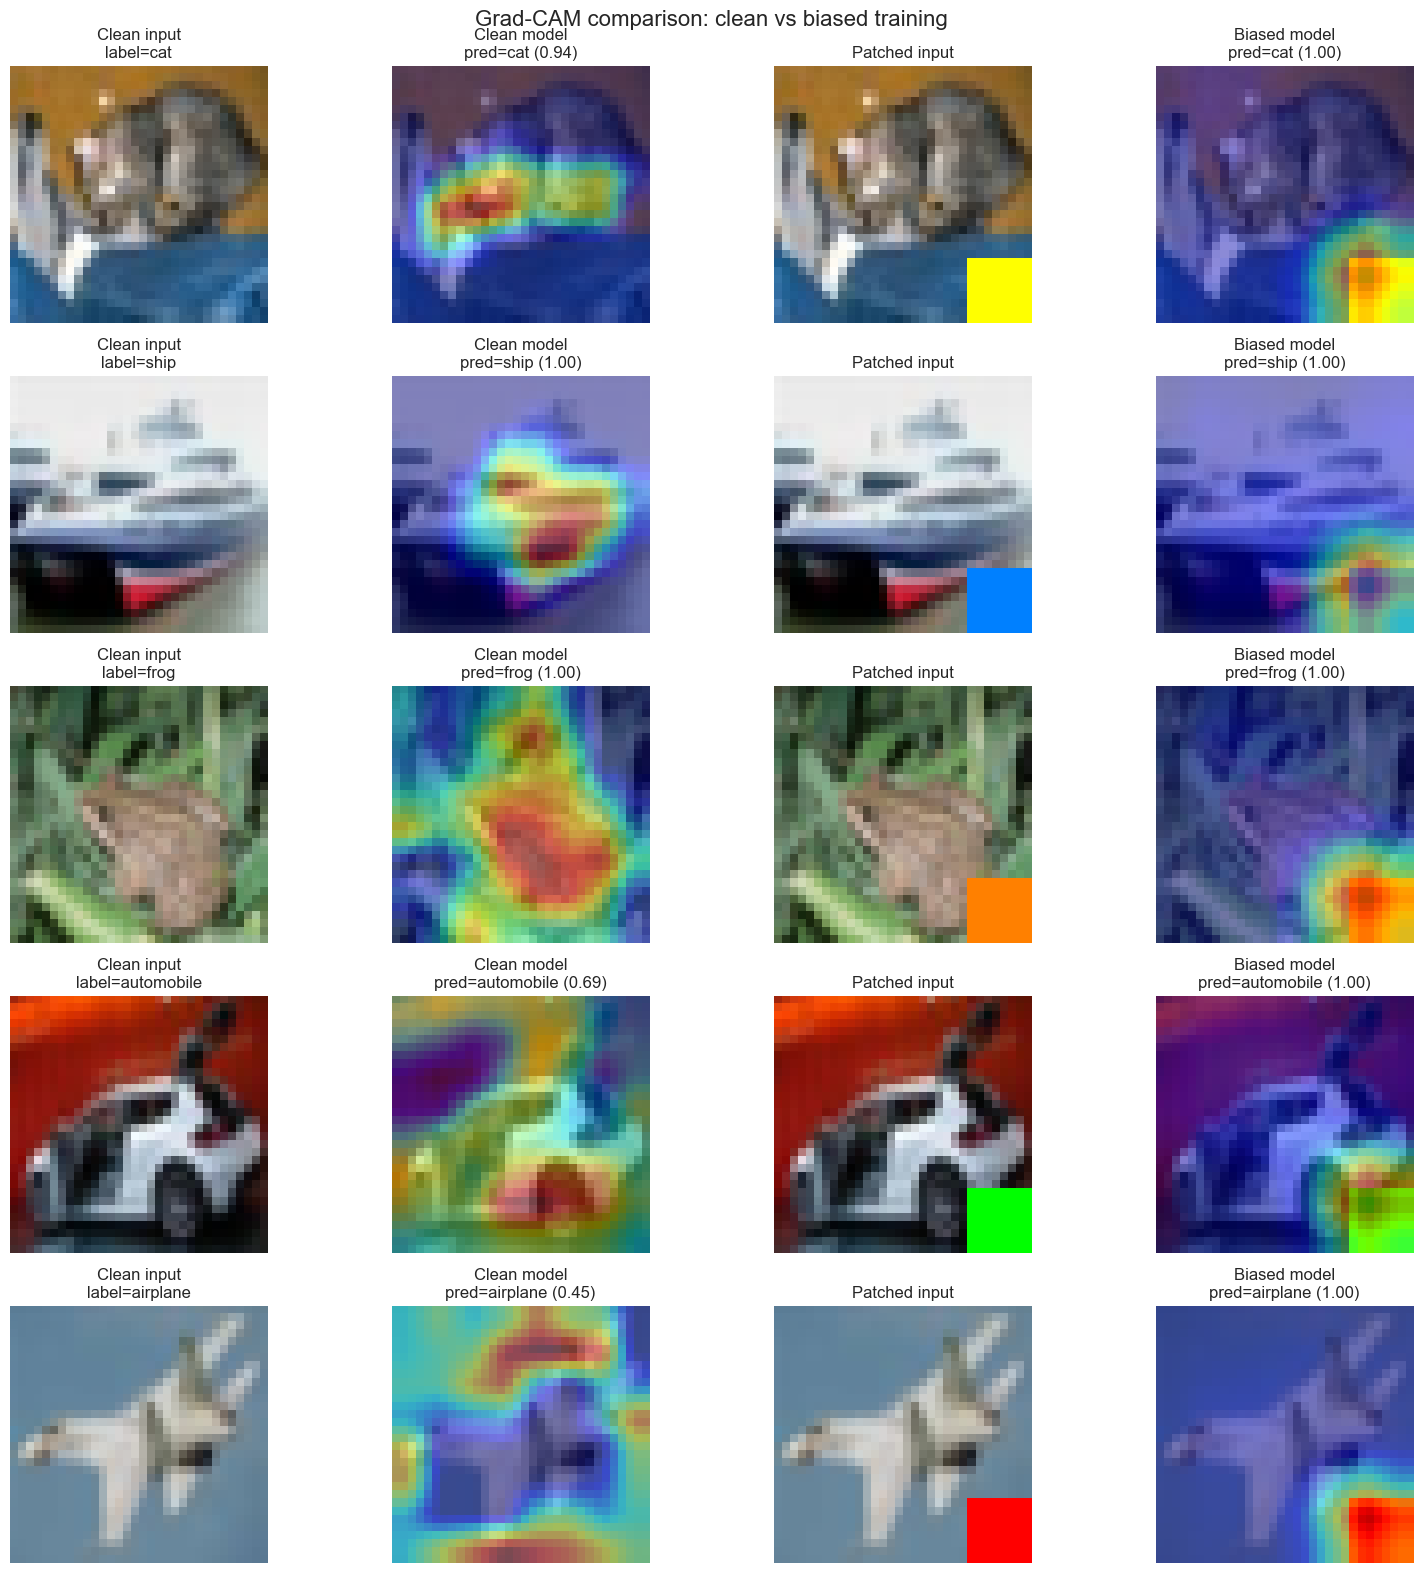

In [17]:
clean_cam = GradCAM(clean_model, clean_model.target_layer)
biased_cam = GradCAM(biased_model, biased_model.target_layer)


def visualize_gradcam_comparison(indices: List[int], use_patched_version_for_biased: bool = True):
    columns = 4
    fig, axes = plt.subplots(len(indices), columns, figsize=(4 * columns, 3.2 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        clean_tensor, label = clean_test_dataset[idx]
        biased_tensor, _ = biased_test_dataset[idx]

        clean_pred, clean_conf = predict_with_confidence(clean_model, clean_tensor)
        biased_input = biased_tensor if use_patched_version_for_biased else clean_tensor
        biased_pred, biased_conf = predict_with_confidence(biased_model, biased_input)

        clean_map = clean_cam(clean_tensor.unsqueeze(0).to(device), target_class=clean_pred)
        biased_map = biased_cam(biased_input.unsqueeze(0).to(device), target_class=biased_pred)

        clean_base, _, clean_overlay = overlay_heatmap(clean_tensor, clean_map)
        biased_base, _, biased_overlay = overlay_heatmap(biased_input, biased_map)

        axes[row, 0].imshow(clean_base)
        axes[row, 0].set_title(f"Clean input\nlabel={class_names[label]}")
        axes[row, 1].imshow(clean_overlay)
        axes[row, 1].set_title(f"Clean model\npred={class_names[clean_pred]} ({clean_conf:.2f})")
        axes[row, 2].imshow(biased_base)
        axes[row, 2].set_title("Patched input" if use_patched_version_for_biased else "Clean input")
        axes[row, 3].imshow(biased_overlay)
        axes[row, 3].set_title(f"Biased model\npred={class_names[biased_pred]} ({biased_conf:.2f})")

        for col in range(columns):
            axes[row, col].axis("off")

    fig.suptitle("Grad-CAM comparison: clean vs biased training", fontsize=16)
    fig.tight_layout()
    plt.show()


visualize_gradcam_comparison(example_indices, use_patched_version_for_biased=True)

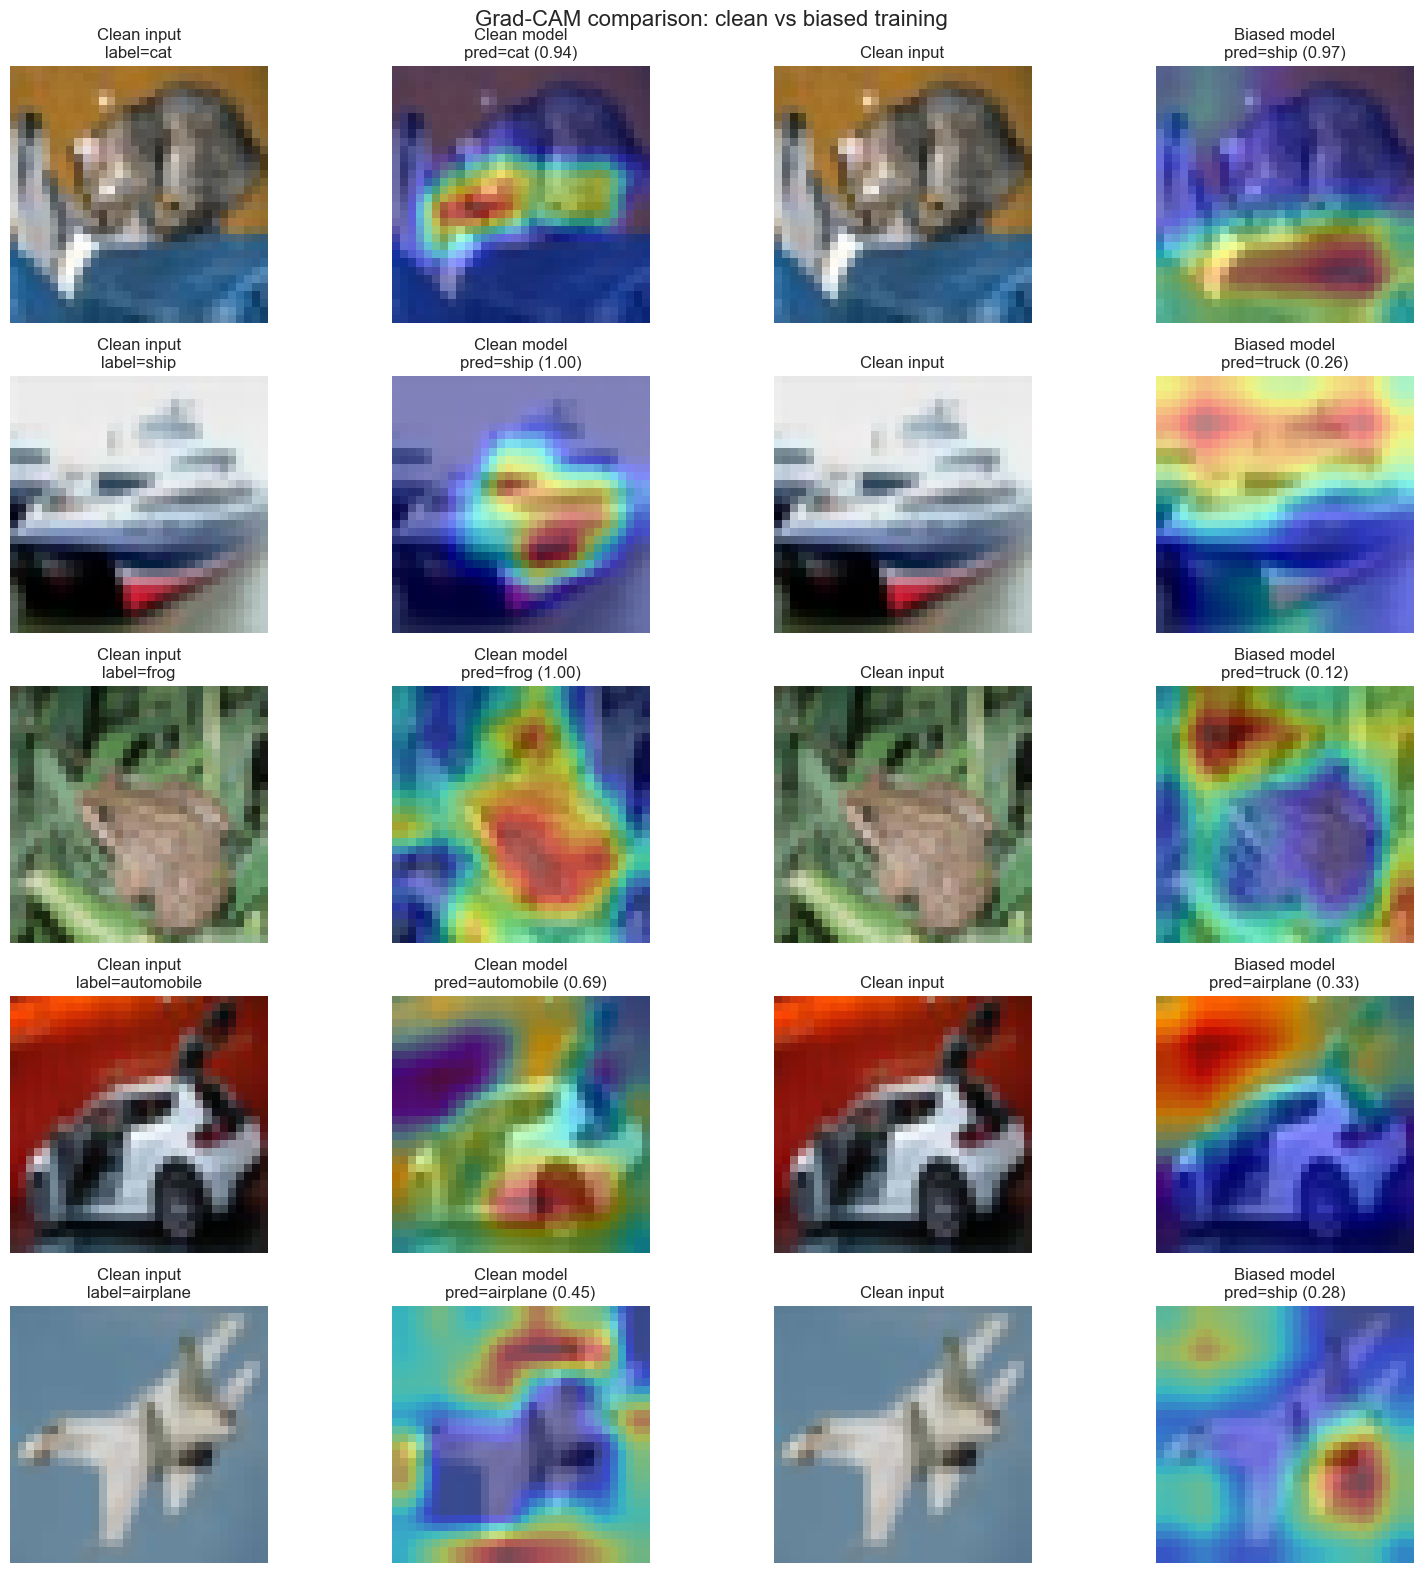

In [18]:
visualize_gradcam_comparison(example_indices, use_patched_version_for_biased=False)

## Confidence drop after masking top-activated regions

Following the proposal, we evaluate explanation usefulness with a simple confidence-drop diagnostic:

1. Compute Grad-CAM for the predicted class.
2. Mask the top-activated fraction of pixels.
3. Measure how much the model's confidence decreases.

Larger drops indicate that the highlighted region mattered more for the prediction.

In [19]:
def confidence_drop_score(model: nn.Module, cam_extractor: GradCAM, dataset: Dataset, sample_count: int = 128, top_fraction: float = 0.2) -> Dict[str, float]:
    sample_count = min(sample_count, len(dataset))
    drops = []

    for idx in range(sample_count):
        image, _ = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = int(probs.argmax(dim=1).item())
        original_conf = float(probs[0, pred_class].item())

        cam_map = cam_extractor(input_tensor, target_class=pred_class)
        threshold = np.quantile(cam_map, 1.0 - top_fraction)
        binary_mask = torch.from_numpy((cam_map >= threshold).astype(np.float32)).to(device).unsqueeze(0).unsqueeze(0)

        masked_input = input_tensor * (1.0 - binary_mask)
        masked_probs = torch.softmax(model(masked_input), dim=1)
        masked_conf = float(masked_probs[0, pred_class].item())
        drops.append(original_conf - masked_conf)

    return {"mean_drop": float(np.mean(drops)), "std_drop": float(np.std(drops)), "samples": sample_count}


clean_drop = confidence_drop_score(clean_model, clean_cam, clean_test_dataset, sample_count=cfg.confidence_drop_samples, top_fraction=cfg.top_fraction)
biased_drop_on_clean = confidence_drop_score(biased_model, biased_cam, clean_test_dataset, sample_count=cfg.confidence_drop_samples, top_fraction=cfg.top_fraction)
biased_drop_on_biased = confidence_drop_score(biased_model, biased_cam, biased_test_dataset, sample_count=cfg.confidence_drop_samples, top_fraction=cfg.top_fraction)

print("Confidence-drop summary")
print("-" * 60)
print(clean_drop)
print(biased_drop_on_clean)
print(biased_drop_on_biased)

Confidence-drop summary
------------------------------------------------------------
{'mean_drop': 0.3859712568832947, 'std_drop': 0.32622587700876354, 'samples': 128}
{'mean_drop': 0.08613145546405576, 'std_drop': 0.1568057065920247, 'samples': 128}
{'mean_drop': 0.8965650395548437, 'std_drop': 0.03465244010852542, 'samples': 128}


## Interpretation notes

Typical outcomes to expect:

- The clean model should maintain better accuracy on the clean test set.
- The biased model often performs better on patched inputs than on clean inputs.
- Grad-CAM for the biased model tends to light up the patch region more strongly on patched images.
- Confidence-drop on patched images can become dominated by the shortcut region, indicating spurious reliance.

Because CIFAR-10 images are only 32x32, Grad-CAM maps are coarse by design. That is expected and matches the method: the explanation is tied to the spatial resolution of the last convolutional layer.